# NB07 - Regenerating the exploratory figures under the corrected protocol

Figures 18, 19, 21-25 of the manuscript (t-SNE, UMAP, corruption robustness, Grad-CAM,
difficulty stratification, efficiency frontier) were produced before the revision, from
checkpoints trained on the **old** splits. This notebook regenerates all of them from the
**NB03/NB04 checkpoints**, which were trained on the specimen-disjoint splits, and evaluates
them on the **common test set** that neither protocol ever trained on.

**Runtime** ~1-1.5 h on one GPU, so it fits a single 12-hour session.

**Attach:** the BDLitchi images, the NB01 splits, the NB03 output, the NB04 output.

**Outputs** land in `/kaggle/working/revision_exploratory/figures/` named `fig18 ... fig25`
so they drop straight into the Overleaf `figures/` folder, plus descriptive copies and the
underlying CSVs.

Sections 1 and 2 need no GPU and no images - they are computed from the saved predictions
and from the architectures alone, so they finish in the first two minutes.

In [1]:
# ===== Imports =====
import json, math, time, io, gc, warnings
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from PIL import Image, ImageEnhance
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
try:
    import timm
except ImportError:
    timm = None
    print('timm not available - EfficientNet/ViT sections will be skipped')
warnings.filterwarnings('ignore')

# ---- identical style to NB06 so the figures match the rest of the paper ----
plt.rcParams.update({
 'figure.dpi':150,'savefig.dpi':300,'font.family':'DejaVu Sans','font.size':10,
 'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
 'grid.alpha':0.22,'grid.linewidth':0.5,'axes.axisbelow':True,
 'axes.edgecolor':'#666666','axes.linewidth':0.8,
 'axes.titlesize':11,'axes.titleweight':'bold','axes.labelsize':10,
 'legend.frameon':False,'xtick.labelsize':9,'ytick.labelsize':9,
 'pdf.fonttype':42,'ps.fonttype':42})

PAL={'MobileNetV3Large':'#8FAFD4','EfficientNetB0':'#F0B48A','EfficientNetB3':'#93C9A5',
     'ResNet50':'#E29497','ViTBase16':'#B3A8D3'}
PAL_DK={'MobileNetV3Large':'#4C72B0','EfficientNetB0':'#DD8452','EfficientNetB3':'#55A868',
        'ResNet50':'#C44E52','ViTBase16':'#8172B3'}
NAT={'MobileNetV3Large':'MobileNetV3-L','EfficientNetB0':'EfficientNet-B0',
     'EfficientNetB3':'EfficientNet-B3','ResNet50':'ResNet-50','ViTBase16':'ViT-Base/16'}

def light_cmap(name, lo=0.0, hi=0.68, n=256):
    base=plt.get_cmap(name)
    return LinearSegmentedColormap.from_list(f'{name}_lt', base(np.linspace(lo,hi,n)))

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| torch', torch.__version__)

device: cuda | torch 2.10.0+cu128


In [2]:
# ===== Config: EDIT THESE FOUR PATHS =====
RAW_DATASET_DIR = '/kaggle/input/datasets/maruf170102/bdlithi/Dataset'
SPLITS_DIR = Path('/kaggle/input/datasets/maruf170102/bdlitchi-revision-splits/revision_splits')
P_CNN      = Path('/kaggle/input/datasets/maruf170102/nb03-result/revision_seeds_cnn')
P_VIT      = Path('/kaggle/input/datasets/maruf170102/nb04-result/revision_seeds_vit')

OUT_DIR = Path('/kaggle/working/revision_exploratory'); OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG = OUT_DIR/'figures'; FIG.mkdir(exist_ok=True)

REF_SEED   = 42        # which seed's checkpoint the per-model figures use
BATCH      = 32
NUM_WORKER = 2

# Corruption grid. 6 x 5 x 1,665 x 5 models is about 250k forward passes (~30-50 min on a T4).
# Trim SEVERITIES to [1,3,5] if you are short of time; the curves stay readable.
CORRUPTIONS = ['gaussian_noise','shot_noise','gaussian_blur','brightness','contrast','jpeg']
SEVERITIES  = [1,2,3,4,5]

def save_fig(fig, name, also_as=None):
    """Write PDF + PNG. `also_as` writes a second copy under the manuscript's figNN name."""
    for ext in ('pdf','png'):
        fig.savefig(FIG/f'{name}.{ext}', bbox_inches='tight', pad_inches=0.06, facecolor='white')
        if also_as:
            fig.savefig(FIG/f'{also_as}.{ext}', bbox_inches='tight', pad_inches=0.06, facecolor='white')
    print(f'  saved {name}' + (f'  (+ {also_as})' if also_as else ''))

for p in [Path(RAW_DATASET_DIR), SPLITS_DIR, P_CNN, P_VIT]:
    print(('OK   ' if p.exists() else 'MISS '), p)

OK    /kaggle/input/datasets/maruf170102/bdlithi/Dataset
OK    /kaggle/input/datasets/maruf170102/bdlitchi-revision-splits/revision_splits
OK    /kaggle/input/datasets/maruf170102/nb03-result/revision_seeds_cnn
OK    /kaggle/input/datasets/maruf170102/nb04-result/revision_seeds_vit


In [3]:
# ===== Data: identical dataset/transform/backbone code to NB03 =====
IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]

class LitchiDataset(Dataset):
    def __init__(self, df, transform, label2idx, corrupt=None):
        self.df=df.reset_index(drop=True); self.t=transform
        self.l2i=label2idx; self.corrupt=corrupt
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]; img=Image.open(r.filepath).convert('RGB')
        if self.corrupt is not None: img=self.corrupt(img)
        return self.t(img), self.l2i[r.label]

def eval_transform(sz):
    return transforms.Compose([transforms.Resize((sz,sz)), transforms.ToTensor(),
                               transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])

def build_backbone(name, nc, pretrained=False):
    if name=='ResNet50':
        m=torchvision.models.resnet50(weights=None); m.fc=nn.Linear(m.fc.in_features,nc); return m,224
    if name=='MobileNetV3Large':
        m=torchvision.models.mobilenet_v3_large(weights=None)
        m.classifier[-1]=nn.Linear(m.classifier[-1].in_features,nc); return m,224
    if name=='EfficientNetB0': return timm.create_model('efficientnet_b0',pretrained=False,num_classes=nc),224
    if name=='EfficientNetB3': return timm.create_model('efficientnet_b3',pretrained=False,num_classes=nc),300
    if name=='ViTBase16':      return timm.create_model('vit_base_patch16_224',pretrained=False,num_classes=nc),224
    raise ValueError(name)

man=pd.read_csv(SPLITS_DIR/'manifest_full.csv')
man['filepath']=[str(Path(RAW_DATASET_DIR)/l/f) for l,f in zip(man.label, man.filename)]
missing=[p for p in man.filepath if not Path(p).exists()]
if missing:
    print(f'*** {len(missing)} of {len(man)} images NOT found. First few:')
    for p in missing[:5]: print('   ',p)
    raise FileNotFoundError('Fix RAW_DATASET_DIR before continuing.')
print(f'OK - all {len(man)} image paths resolve.')

CLASSES=sorted(man.label.unique()); NC=len(CLASSES)
label2idx={c:i for i,c in enumerate(CLASSES)}
test=man[man.reserve=='common_test'].copy()
print(f'common test: {len(test)} images, {test.specimen_id.nunique()} specimens, {NC} classes')

CKPT={}
for d in [P_CNN,P_VIT]:
    cd=d/'checkpoints'
    if cd.exists():
        for f in sorted(cd.glob('*.pt')): CKPT[f.stem]=f
print(f'checkpoints found: {len(CKPT)}')
print(' ', sorted(CKPT)[:6], '...')

OK - all 11094 image paths resolve.
common test: 1665 images, 265 specimens, 11 classes
checkpoints found: 15
  ['EfficientNetB0_seed123', 'EfficientNetB0_seed42', 'EfficientNetB0_seed7', 'EfficientNetB3_seed123', 'EfficientNetB3_seed42', 'EfficientNetB3_seed7'] ...


## 1. Efficiency frontier (Fig. 25) - no GPU, no images

In [4]:
# ===== 1. Efficiency frontier =====
# Accuracy comes from the NB03/NB04 independent runs (mean over seeds). Cost is measured
# from the architecture itself, so this section needs neither the dataset nor a GPU.
runs=[]
for d in [P_CNN,P_VIT]:
    f=d/'independent_runs.csv'
    if f.exists(): runs.append(pd.read_csv(f))
runs=pd.concat(runs,ignore_index=True)
acc=runs.groupby('model')[['accuracy','f1_macro']].agg(['mean','std'])

def count_params(m): return sum(p.numel() for p in m.parameters())

def bench_latency(m, sz, device, n=30, warmup=8):
    m=m.to(device).eval()
    x=torch.randn(1,3,sz,sz,device=device)
    with torch.no_grad():
        for _ in range(warmup): m(x)
        if device=='cuda': torch.cuda.synchronize()
        t0=time.perf_counter()
        for _ in range(n): m(x)
        if device=='cuda': torch.cuda.synchronize()
        return (time.perf_counter()-t0)/n*1000  # ms

rows=[]
for name in [m for m in PAL if m in set(runs.model)]:
    if name in ('EfficientNetB0','EfficientNetB3','ViTBase16') and timm is None: continue
    m,sz=build_backbone(name,NC)
    p=count_params(m)
    lat_cpu=bench_latency(m,sz,'cpu',n=10,warmup=3)
    lat_gpu=bench_latency(m,sz,'cuda') if DEVICE=='cuda' else np.nan
    rows.append({'model':name,'Model':NAT[name],'params_M':p/1e6,'input':sz,
                 'cpu_ms':lat_cpu,'gpu_ms':lat_gpu,
                 'accuracy':acc.loc[name,('accuracy','mean')],
                 'acc_sd':acc.loc[name,('accuracy','std')],
                 'f1_macro':acc.loc[name,('f1_macro','mean')]})
    del m; gc.collect()
    if DEVICE=='cuda': torch.cuda.empty_cache()

eff=pd.DataFrame(rows)
eff.to_csv(OUT_DIR/'efficiency.csv',index=False)
print(eff.round(3).to_string(index=False))

           model           Model  params_M  input  cpu_ms  gpu_ms  accuracy  acc_sd  f1_macro
MobileNetV3Large   MobileNetV3-L     4.216    224  29.128   6.665     0.989   0.005     0.989
  EfficientNetB0 EfficientNet-B0     4.022    224  41.316   8.839     0.983   0.010     0.983
  EfficientNetB3 EfficientNet-B3    10.713    300 130.038  14.059     0.981   0.005     0.982
        ResNet50       ResNet-50    23.531    224  88.753   7.217     0.988   0.003     0.988
       ViTBase16     ViT-Base/16    85.807    224 249.067  13.808     0.912   0.023     0.914


  saved fig_efficiency_frontier  (+ fig25)


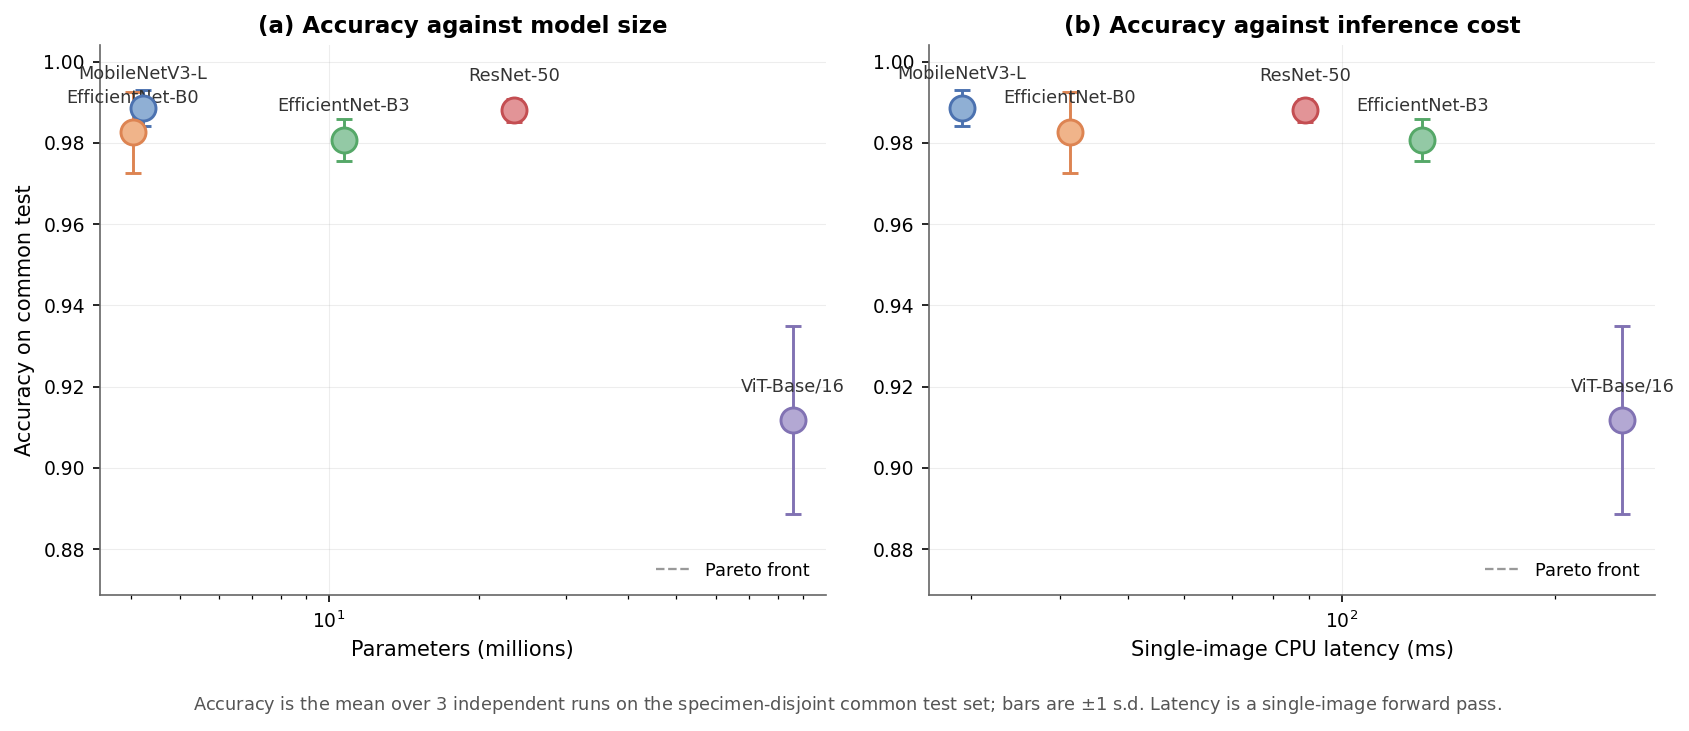

In [5]:
# ===== 1b. Efficiency figure =====
fig,axes=plt.subplots(1,2,figsize=(11.4,4.6))
for ax,(xcol,xlab,title) in zip(axes,[
        ('params_M','Parameters (millions)','(a) Accuracy against model size'),
        ('cpu_ms','Single-image CPU latency (ms)','(b) Accuracy against inference cost')]):
    for _,r in eff.iterrows():
        ax.errorbar(r[xcol], r.accuracy, yerr=(0 if np.isnan(r.acc_sd) else r.acc_sd),
                    fmt='o', ms=12, capsize=4, elinewidth=1.4,
                    color=PAL[r.model], markeredgecolor=PAL_DK[r.model],
                    markeredgewidth=1.4, ecolor=PAL_DK[r.model], zorder=3)
        ax.annotate(r.Model,(r[xcol],r.accuracy),textcoords='offset points',
                    xytext=(0,14),ha='center',fontsize=8.5,color='#333')
    # Pareto front: nothing cheaper is also more accurate
    d=eff.sort_values(xcol); best=-np.inf; px=[]; py=[]
    for _,r in d.iterrows():
        if r.accuracy>best: best=r.accuracy; px.append(r[xcol]); py.append(r.accuracy)
    ax.plot(px,py,'--',color='#999',lw=1.1,zorder=1,label='Pareto front')
    ax.set_xlabel(xlab); ax.set_title(title)
    ax.set_xscale('log'); ax.legend(fontsize=8.5,loc='lower right')
    lo=float((eff.accuracy-eff.acc_sd.fillna(0)).min()); hi=float(eff.accuracy.max())
    ax.set_ylim(lo-0.02, min(1.004,hi+0.02))
axes[0].set_ylabel('Accuracy on common test'); axes[1].set_ylabel('')
fig.text(0.5,-0.04,'Accuracy is the mean over 3 independent runs on the specimen-disjoint '
         'common test set; bars are $\\pm$1 s.d. Latency is a single-image forward pass.',
         ha='center',fontsize=8.5,color='#555')
plt.tight_layout(); save_fig(fig,'fig_efficiency_frontier',also_as='fig25'); plt.show()

## 2. Difficulty stratification (Fig. 24) - from saved predictions, no inference

In [6]:
# ===== 2. Difficulty stratification =====
# How many of the 15 independent runs (5 architectures x 3 seeds) classify each test image
# correctly? This needs no re-inference: it is read straight out of the saved predictions.
pred={}
for d in [P_CNN,P_VIT]:
    pdir=d/'predictions'
    if pdir.exists():
        for f in sorted(pdir.glob('*.npz')): pred[f.stem]=np.load(f,allow_pickle=True)
print(f'{len(pred)} prediction files')

ref=pred[sorted(pred)[0]]
files=ref['filename']; y=ref['y_true']; spec=ref['specimen_id'].astype(str)
correct=np.zeros(len(files),dtype=int)
for tag,d in pred.items():
    assert np.array_equal(d['filename'],files), f'{tag}: prediction files are not aligned'
    correct += (d['y_pred']==d['y_true']).astype(int)
NRUN=len(pred)

dif=pd.DataFrame({'filename':files,'label':[CLASSES[i] for i in y],
                  'specimen_id':spec,'n_correct':correct})
dif['frac']=dif.n_correct/NRUN
def band(n):
    if n==NRUN: return 'solved by all'
    if n>=int(0.8*NRUN): return 'easy'
    if n>=int(0.5*NRUN): return 'moderate'
    if n>0: return 'hard'
    return 'never solved'
dif['difficulty']=dif.n_correct.map(band)
dif.to_csv(OUT_DIR/'difficulty_per_image.csv',index=False)

ORDER=['solved by all','easy','moderate','hard','never solved']
tab=(dif.groupby(['label','difficulty']).size().unstack(fill_value=0)
       .reindex(columns=ORDER,fill_value=0))
tab_pct=tab.div(tab.sum(1),axis=0)*100
tab.to_csv(OUT_DIR/'difficulty_by_class.csv')
print(tab.to_string())
print(f'\nImages never classified correctly by ANY of the {NRUN} runs: '
      f'{(dif.n_correct==0).sum()}  ({(dif.n_correct==0).mean():.2%})')
print(f'Images solved by all {NRUN}: {(dif.n_correct==NRUN).sum()}  '
      f'({(dif.n_correct==NRUN).mean():.2%})')
print(f'Specimens containing at least one never-solved image: '
      f'{dif[dif.n_correct==0].specimen_id.nunique()} of {dif.specimen_id.nunique()}')

15 prediction files
difficulty              solved by all  easy  moderate  hard  never solved
label                                                                    
Black Spot                        126    28         3     0             0
Burned Leaf                       118    49         7     1             0
Dried Leaf                        138     2         0     0             0
Fungal Stripe Damage              121    14         4     0             0
Healthy Leaf                      136    13         0     0             0
Insect Chewing Damage             128    45         0     0             0
Leaf Blight Disease               133    11         0     0             0
Pest-Affected Dry Leaf            112    19         1     0             0
Red Rust Disease                   88    31        30    14             0
White Spot                        120    12         0     0             0
Yellow Mosaic Virus               151    10         0     0             0

Images never clas

  saved fig_difficulty_stratification  (+ fig24)


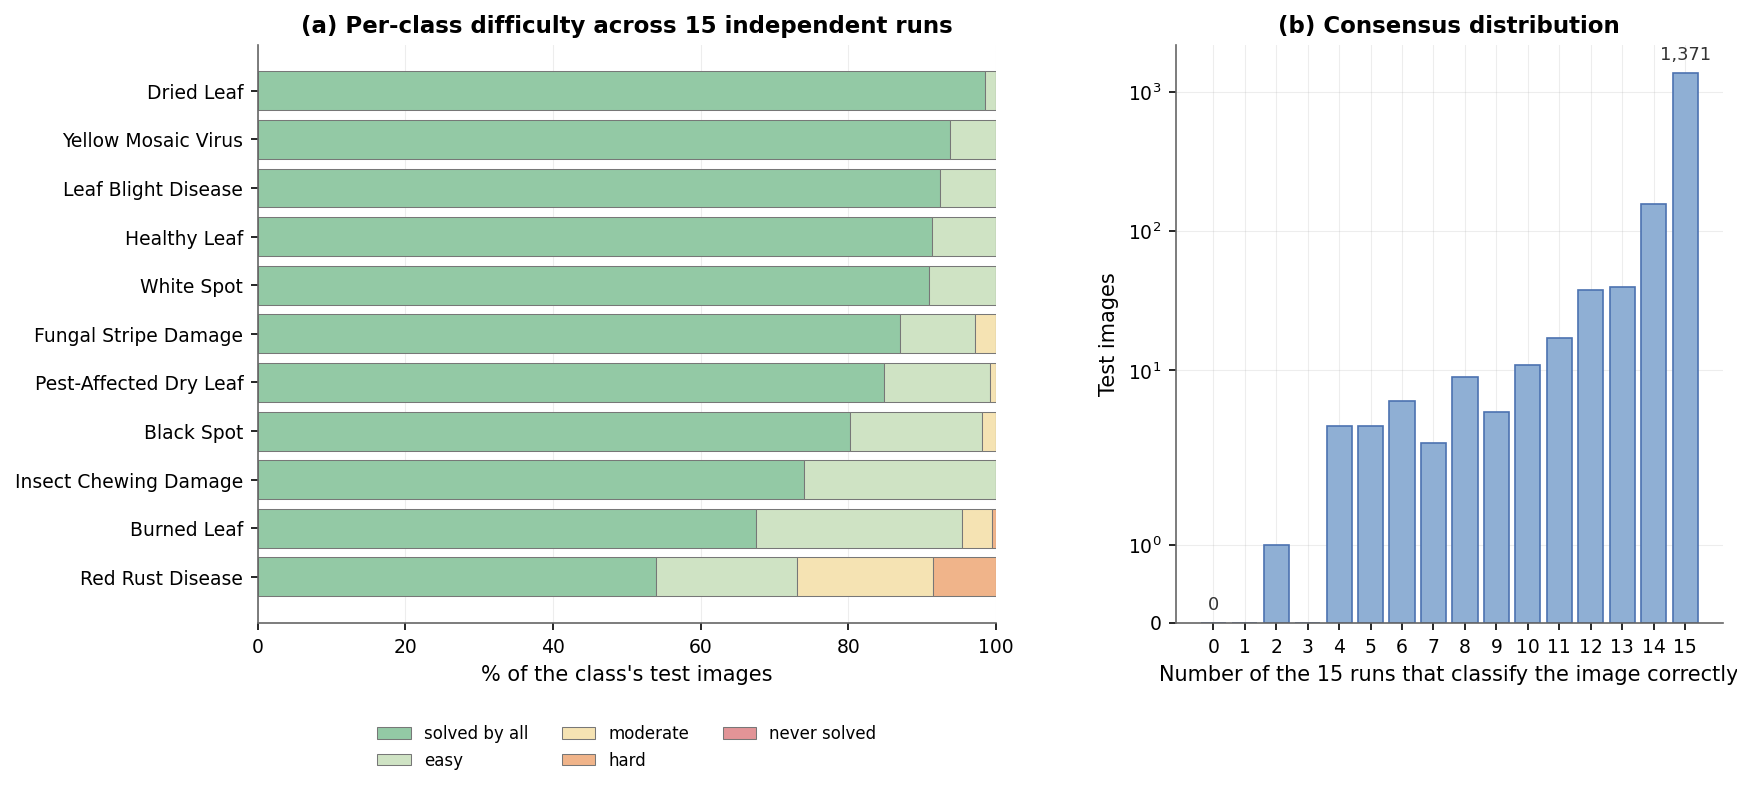

In [7]:
# ===== 2b. Difficulty figure =====
fig,axes=plt.subplots(1,2,figsize=(12.6,5.0),
                      gridspec_kw={'width_ratios':[1.35,1],'wspace':0.28})
SH={'solved by all':'#93C9A5','easy':'#CFE3C4','moderate':'#F5E3B3',
    'hard':'#F0B48A','never solved':'#E29497'}
ax=axes[0]
order=tab_pct['solved by all'].sort_values(ascending=False).index
left=np.zeros(len(order))
for b in ORDER:
    v=tab_pct.loc[order,b].values
    ax.barh(np.arange(len(order)),v,left=left,color=SH[b],
            edgecolor='#777',lw=.5,label=b)
    left+=v
ax.set_yticks(np.arange(len(order))); ax.set_yticklabels(order,fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0,100); ax.set_xlabel("% of the class's test images")
ax.set_title(f'(a) Per-class difficulty across {NRUN} independent runs')
ax.grid(axis='y',visible=False)
ax.legend(fontsize=8,ncol=3,loc='lower center',bbox_to_anchor=(0.5,-0.28))
ax=axes[1]
cnt=dif.n_correct.value_counts().reindex(range(NRUN+1),fill_value=0)
ax.bar(cnt.index,cnt.values,color='#8FAFD4',edgecolor='#4C72B0',lw=.8)
ax.set_xlabel(f'Number of the {NRUN} runs that classify the image correctly')
ax.set_ylabel('Test images'); ax.set_yscale('symlog')
ax.set_title('(b) Consensus distribution')
ax.set_xticks(range(0,NRUN+1,max(1,NRUN//8)))
for x in (0,NRUN):
    ax.annotate(f'{cnt[x]:,}',(x,cnt[x]),textcoords='offset points',xytext=(0,6),
                ha='center',fontsize=8.5,color='#333')
plt.tight_layout(); save_fig(fig,'fig_difficulty_stratification',also_as='fig24'); plt.show()

## 3. Feature space: t-SNE and UMAP (Figs. 18-19)

One forward pass per architecture over the 1,665 common-test images, taking the penultimate
layer. Both projections are fitted on the **same** feature matrix so the two figures are
directly comparable.

In [8]:
# ===== 3. Penultimate-layer features =====
def make_extractor(name, model):
    """Return a callable giving penultimate-layer features for a batch."""
    if name=='ResNet50':
        body=nn.Sequential(*list(model.children())[:-1])
        return lambda x: body(x).flatten(1)
    if name=='MobileNetV3Large':
        def f(x):
            z=model.features(x); z=model.avgpool(z).flatten(1)
            return model.classifier[:-1](z)
        return f
    # timm models (EfficientNet, ViT) expose pre_logits through forward_head
    return lambda x: model.forward_head(model.forward_features(x), pre_logits=True)

@torch.no_grad()
def extract(name, ckpt_path, df):
    model,sz=build_backbone(name,NC)
    sd=torch.load(ckpt_path,map_location='cpu')
    model.load_state_dict(sd['model'] if isinstance(sd,dict) and 'model' in sd else sd)
    model=model.to(DEVICE).eval()
    fx=make_extractor(name,model)
    dl=DataLoader(LitchiDataset(df,eval_transform(sz),label2idx),
                  batch_size=BATCH,shuffle=False,num_workers=NUM_WORKER,pin_memory=True)
    Z=[]; Y=[]
    for xb,yb in dl:
        Z.append(fx(xb.to(DEVICE,non_blocking=True)).float().cpu().numpy()); Y.append(yb.numpy())
    del model; gc.collect()
    if DEVICE=='cuda': torch.cuda.empty_cache()
    return np.concatenate(Z), np.concatenate(Y)

FEAT={}
for name in PAL:
    tag=f'{name}_seed{REF_SEED}'
    if tag not in CKPT: print(f'  skip {name}: no checkpoint {tag}'); continue
    if name in ('EfficientNetB0','EfficientNetB3','ViTBase16') and timm is None: continue
    t0=time.time(); Z,Y=extract(name,CKPT[tag],test)
    FEAT[name]=(Z,Y); print(f'  {NAT[name]:18s} {Z.shape}  ({time.time()-t0:.0f}s)')
if FEAT:
    np.savez_compressed(OUT_DIR/f'features_seed{REF_SEED}.npz',
                        **{k:v[0] for k,v in FEAT.items()},
                        y=list(FEAT.values())[0][1])

  MobileNetV3-L      (1665, 1280)  (12s)
  EfficientNet-B0    (1665, 1280)  (8s)
  EfficientNet-B3    (1665, 1536)  (10s)
  ResNet-50          (1665, 2048)  (12s)
  ViT-Base/16        (1665, 768)  (23s)


  projected MobileNetV3-L
  projected EfficientNet-B0
  projected EfficientNet-B3
  projected ResNet-50
  projected ViT-Base/16
  saved fig_tsne_feature_space  (+ fig18)


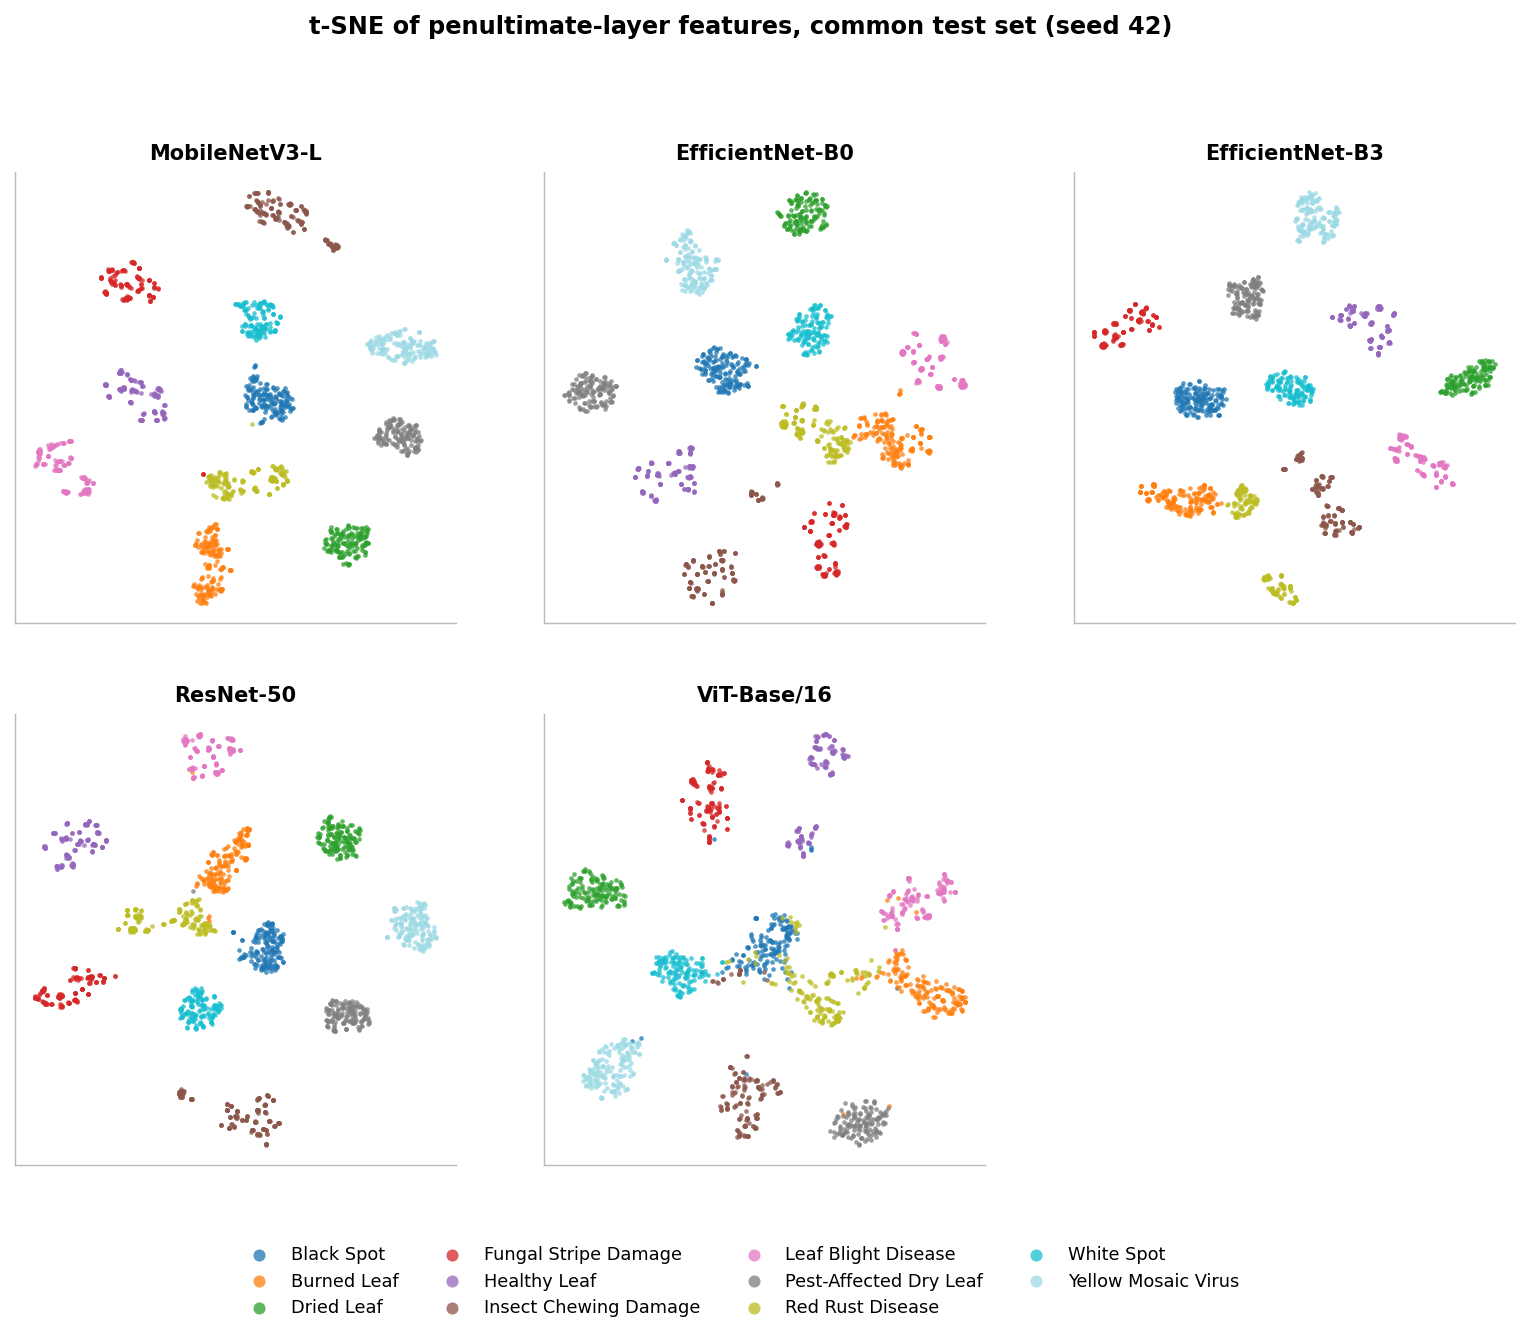

  saved fig_umap_feature_space  (+ fig19)


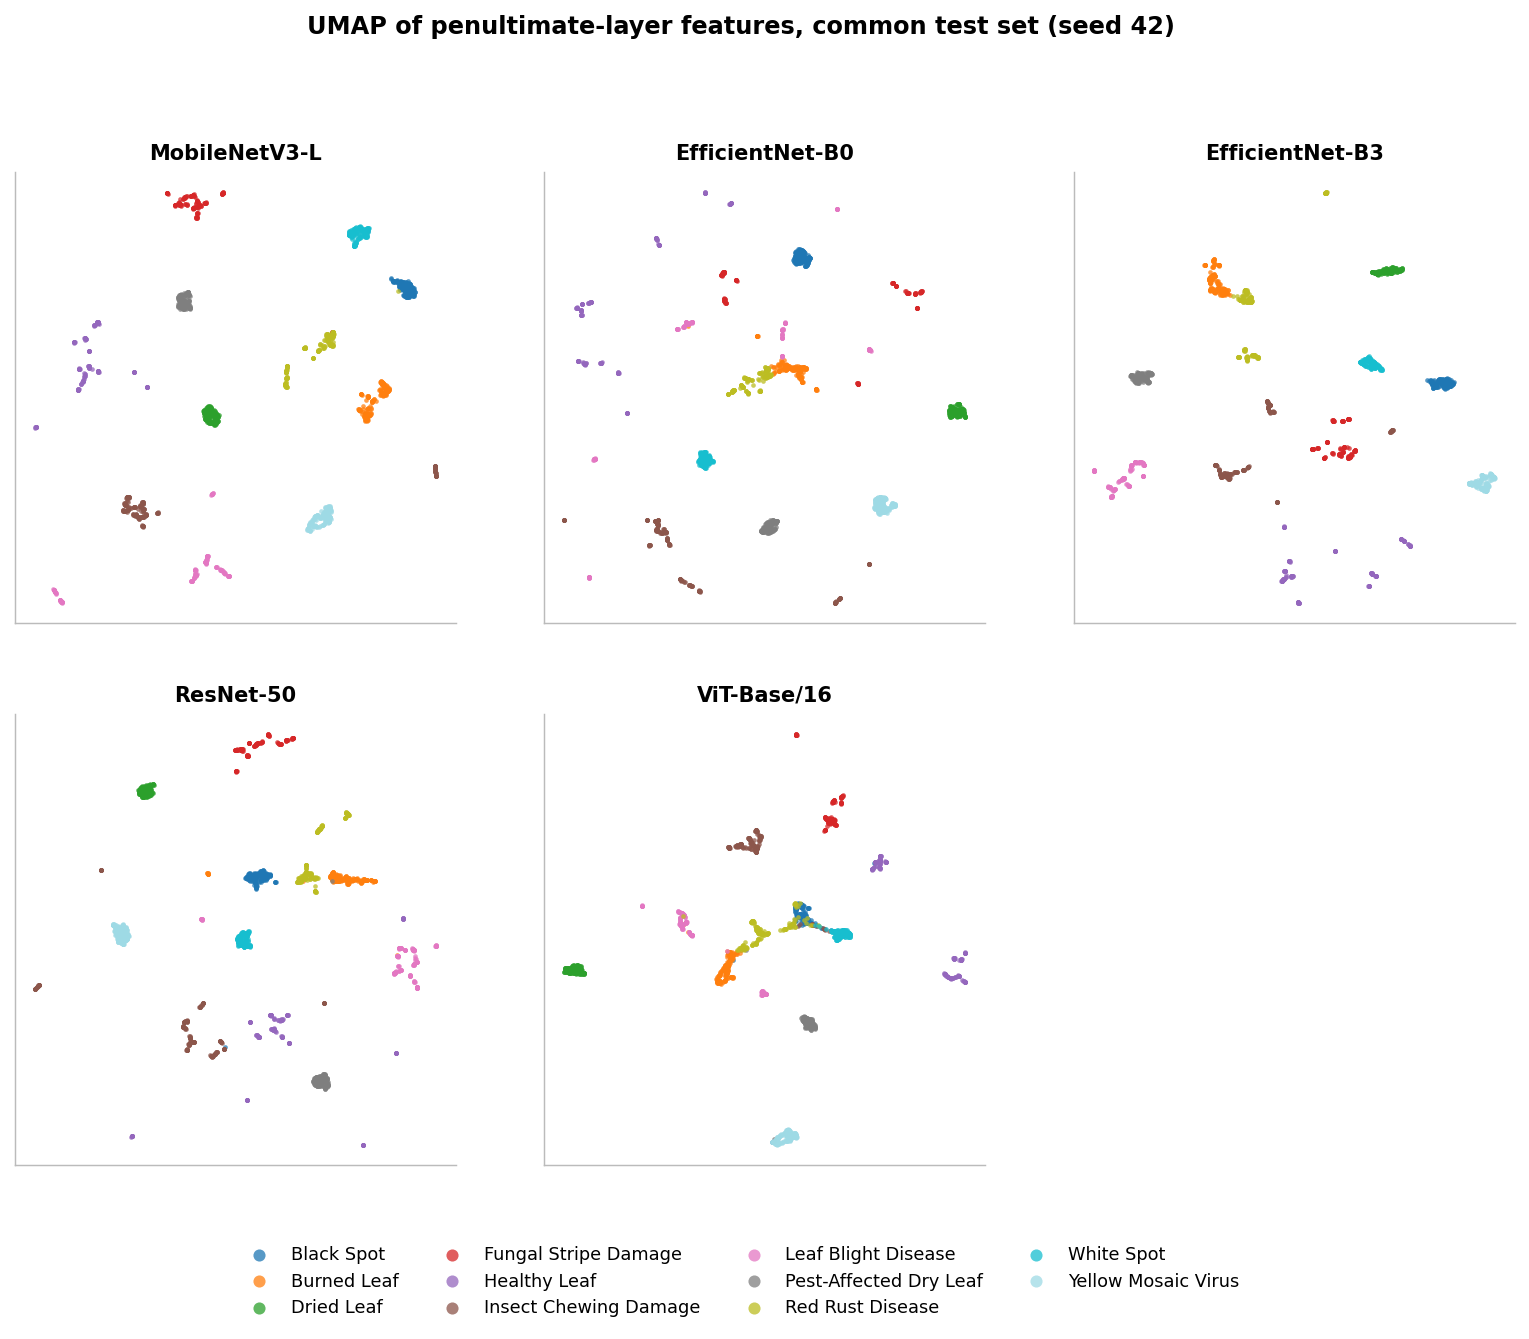

In [9]:
# ===== 3b. t-SNE and UMAP projections =====
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
try:
    import umap
    HAVE_UMAP=True
except ImportError:
    HAVE_UMAP=False
    print('umap-learn not installed - UMAP panel will be skipped.')
    print('To enable it:  !pip install -q umap-learn   then re-run this cell.')

PROJ={}
for name,(Z,Y) in FEAT.items():
    Zs=StandardScaler().fit_transform(Z)
    ts=TSNE(n_components=2,perplexity=30,init='pca',random_state=0,
            learning_rate='auto').fit_transform(Zs)
    um=umap.UMAP(n_neighbors=15,min_dist=0.1,random_state=0).fit_transform(Zs) if HAVE_UMAP else None
    PROJ[name]=(ts,um,Y); print(f'  projected {NAT[name]}')

CCOL=plt.get_cmap('tab20')(np.linspace(0,1,NC))
def panel_grid(kind, idx, fname, also):
    items=[(n,p[idx]) for n,p in PROJ.items() if p[idx] is not None]
    if not items: print(f'  {kind}: nothing to plot'); return
    n=len(items); ncol=min(3,n); nrow=int(np.ceil(n/ncol))
    fig,axes=plt.subplots(nrow,ncol,figsize=(4.3*ncol,4.3*nrow),squeeze=False)
    for ax in axes.ravel(): ax.axis('off')
    for k,(name,E) in enumerate(items):
        ax=axes[k//ncol][k%ncol]; ax.axis('on')
        Y=PROJ[name][2]
        for ci in range(NC):
            m=Y==ci
            ax.scatter(E[m,0],E[m,1],s=5,color=CCOL[ci],alpha=.75,linewidths=0,
                       label=CLASSES[ci] if k==0 else None)
        ax.set_title(NAT[name],fontsize=10); ax.set_xticks([]); ax.set_yticks([])
        ax.grid(False)
        for s in ax.spines.values(): s.set_color('#bbb'); s.set_linewidth(.7)
    h,l=axes[0][0].get_legend_handles_labels()
    fig.legend(h,l,loc='lower center',ncol=4,fontsize=8.5,markerscale=2.6,
               bbox_to_anchor=(0.5,-0.02 if nrow>1 else -0.12))
    fig.suptitle(f'{kind} of penultimate-layer features, common test set (seed {REF_SEED})',
                 fontsize=11.5,fontweight='bold',y=1.002)
    save_fig(fig,fname,also_as=also); plt.show()

panel_grid('t-SNE',0,'fig_tsne_feature_space','fig18')
panel_grid('UMAP', 1,'fig_umap_feature_space','fig19')

## 4. Corruption robustness (Figs. 21-22)

Six corruptions at five severities, applied to the common test set, for every architecture.

We deliberately do **not** report mean Corruption Error (mCE). mCE is normalised by an
AlexNet baseline that was never run here, and the earlier manuscript's mCE numbers were
withdrawn for exactly that reason. What is reported instead is plain accuracy under
corruption and the relative degradation from clean accuracy, both of which are
self-contained and need no external baseline.

  saved fig_corruption_examples


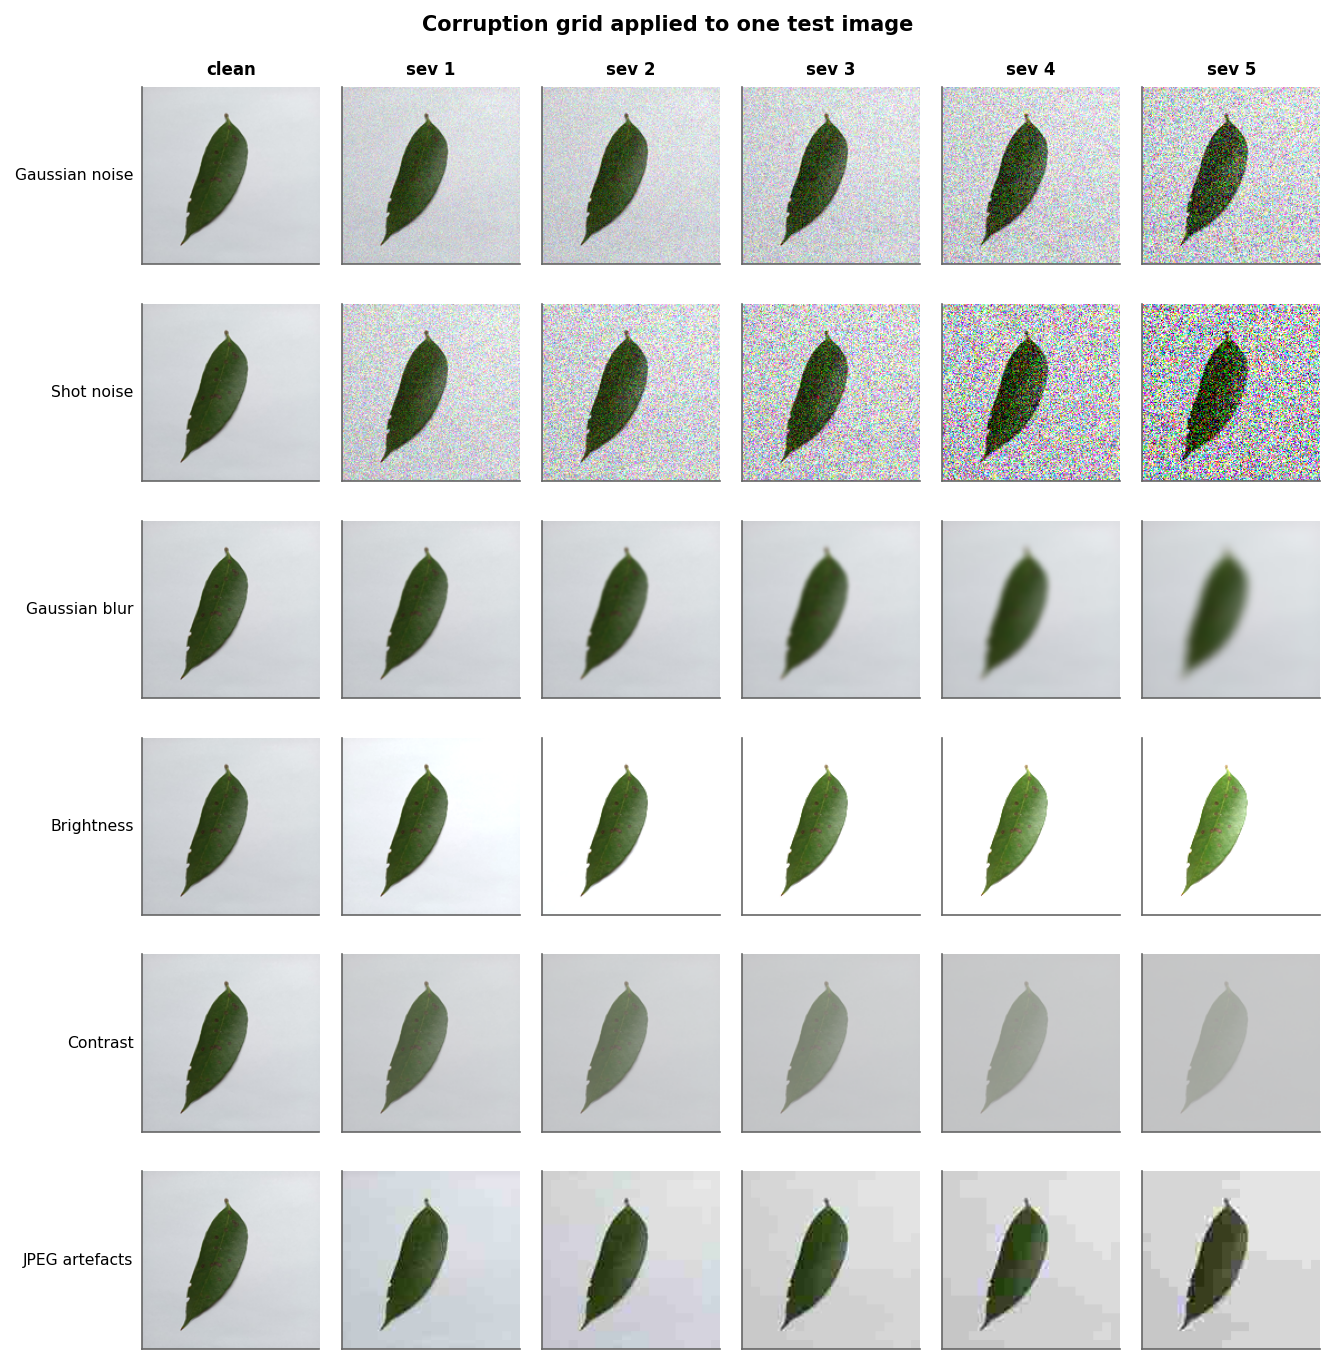

In [10]:
# ===== 4. Corruption functions (self-contained: no imagecorruptions dependency) =====
def _np(img): return np.asarray(img).astype(np.float32)/255.
def _pil(a):  return Image.fromarray((np.clip(a,0,1)*255).astype(np.uint8))

def gaussian_noise(img,s):
    c=[.04,.06,.10,.15,.22][s-1]; a=_np(img)
    return _pil(a+np.random.normal(size=a.shape,scale=c))
def shot_noise(img,s):
    c=[60,25,12,5,3][s-1]; a=_np(img)
    return _pil(np.random.poisson(a*c)/float(c))
def gaussian_blur(img,s):
    from PIL import ImageFilter
    return img.filter(ImageFilter.GaussianBlur([.6,1.,1.7,2.6,4.][s-1]))
def brightness(img,s):
    return ImageEnhance.Brightness(img).enhance([1.15,1.30,1.50,1.75,2.05][s-1])
def contrast(img,s):
    return ImageEnhance.Contrast(img).enhance([.75,.60,.45,.30,.20][s-1])
def jpeg(img,s):
    q=[28,20,15,10,7][s-1]; b=io.BytesIO(); img.save(b,'JPEG',quality=q); b.seek(0)
    return Image.open(b).convert('RGB')

CORRUPT_FN={'gaussian_noise':gaussian_noise,'shot_noise':shot_noise,
            'gaussian_blur':gaussian_blur,'brightness':brightness,
            'contrast':contrast,'jpeg':jpeg}
PRETTY={'gaussian_noise':'Gaussian noise','shot_noise':'Shot noise',
        'gaussian_blur':'Gaussian blur','brightness':'Brightness',
        'contrast':'Contrast','jpeg':'JPEG artefacts'}

# quick visual sanity check that the corruptions do what they claim
_img=Image.open(test.iloc[0].filepath).convert('RGB').resize((160,160))
fig,axes=plt.subplots(len(CORRUPTIONS),len(SEVERITIES)+1,
                      figsize=(1.5*(len(SEVERITIES)+1),1.55*len(CORRUPTIONS)))
for i,c in enumerate(CORRUPTIONS):
    axes[i][0].imshow(_img); axes[i][0].set_ylabel(PRETTY[c],fontsize=7.5,rotation=0,
                                                   ha='right',va='center',labelpad=4)
    if i==0: axes[i][0].set_title('clean',fontsize=8)
    for j,s in enumerate(SEVERITIES):
        axes[i][j+1].imshow(CORRUPT_FN[c](_img,s))
        if i==0: axes[i][j+1].set_title(f'sev {s}',fontsize=8)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle('Corruption grid applied to one test image',fontsize=10,fontweight='bold')
plt.tight_layout(); save_fig(fig,'fig_corruption_examples'); plt.show()

In [11]:
# ===== 4b. Evaluate every model under every corruption =====
@torch.no_grad()
def accuracy_under(model, sz, fn, sev):
    c=(lambda im: fn(im,sev)) if fn else None
    dl=DataLoader(LitchiDataset(test,eval_transform(sz),label2idx,corrupt=c),
                  batch_size=BATCH,shuffle=False,num_workers=NUM_WORKER,pin_memory=True)
    ok=tot=0
    for xb,yb in dl:
        p=model(xb.to(DEVICE,non_blocking=True)).argmax(1).cpu()
        ok+=(p==yb).sum().item(); tot+=len(yb)
    return ok/tot

rob=[]; np.random.seed(0)
for name in PAL:
    tag=f'{name}_seed{REF_SEED}'
    if tag not in CKPT: continue
    if name in ('EfficientNetB0','EfficientNetB3','ViTBase16') and timm is None: continue
    model,sz=build_backbone(name,NC)
    sd=torch.load(CKPT[tag],map_location='cpu')
    model.load_state_dict(sd['model'] if isinstance(sd,dict) and 'model' in sd else sd)
    model=model.to(DEVICE).eval()
    clean=accuracy_under(model,sz,None,0)
    rob.append({'model':name,'corruption':'clean','severity':0,'accuracy':clean})
    print(f'{NAT[name]:18s} clean {clean:.4f}')
    for cname in CORRUPTIONS:
        for s in SEVERITIES:
            t0=time.time(); a=accuracy_under(model,sz,CORRUPT_FN[cname],s)
            rob.append({'model':name,'corruption':cname,'severity':s,'accuracy':a})
            print(f'   {cname:15s} sev{s}  {a:.4f}   ({time.time()-t0:.0f}s)')
    del model; gc.collect()
    if DEVICE=='cuda': torch.cuda.empty_cache()

rob=pd.DataFrame(rob); rob.to_csv(OUT_DIR/'robustness.csv',index=False)
clean_acc=rob[rob.corruption=='clean'].set_index('model').accuracy
print('\ndone')

MobileNetV3-L      clean 0.9928
   gaussian_noise  sev1  0.8649   (41s)
   gaussian_noise  sev2  0.7267   (37s)
   gaussian_noise  sev3  0.5375   (36s)
   gaussian_noise  sev4  0.4420   (38s)
   gaussian_noise  sev5  0.3982   (40s)
   shot_noise      sev1  0.6186   (94s)
   shot_noise      sev2  0.5039   (101s)
   shot_noise      sev3  0.4426   (114s)
   shot_noise      sev4  0.4000   (85s)
   shot_noise      sev5  0.3321   (72s)
   gaussian_blur   sev1  0.9928   (18s)
   gaussian_blur   sev2  0.9928   (20s)
   gaussian_blur   sev3  0.9892   (19s)
   gaussian_blur   sev4  0.9796   (19s)
   gaussian_blur   sev5  0.9405   (19s)
   brightness      sev1  0.9886   (10s)
   brightness      sev2  0.9405   (9s)
   brightness      sev3  0.9351   (9s)
   brightness      sev4  0.9219   (9s)
   brightness      sev5  0.8559   (9s)
   contrast        sev1  0.9922   (10s)
   contrast        sev2  0.9898   (10s)
   contrast        sev3  0.9802   (10s)
   contrast        sev4  0.9489   (10s)
   contras

  saved fig_robustness_heatmap  (+ fig21)


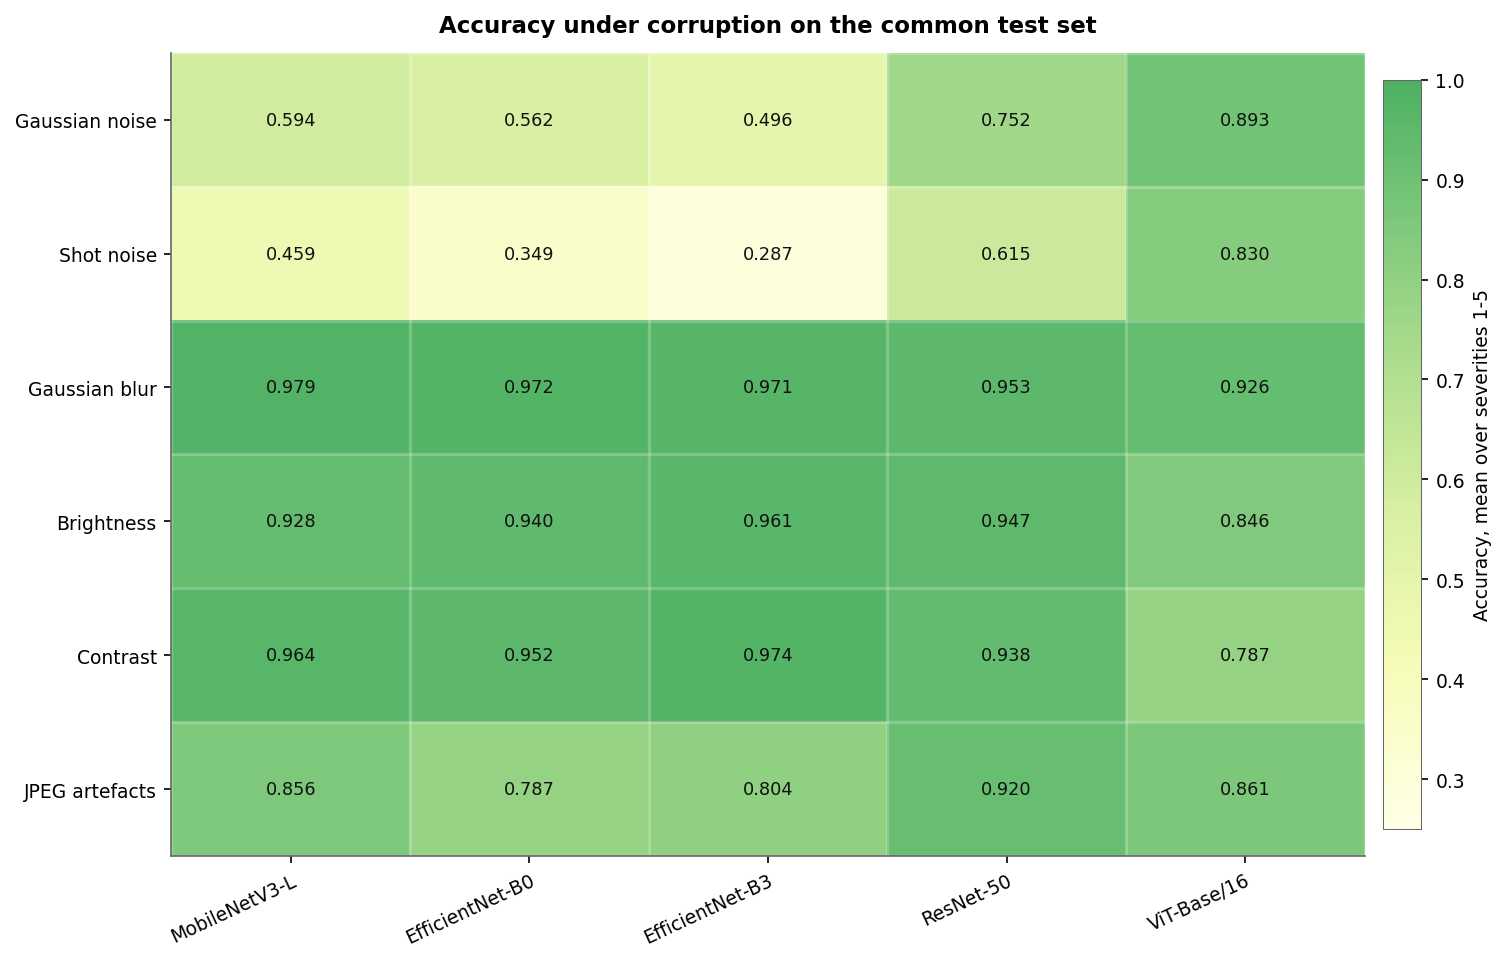

  saved fig_robustness_degradation  (+ fig22)


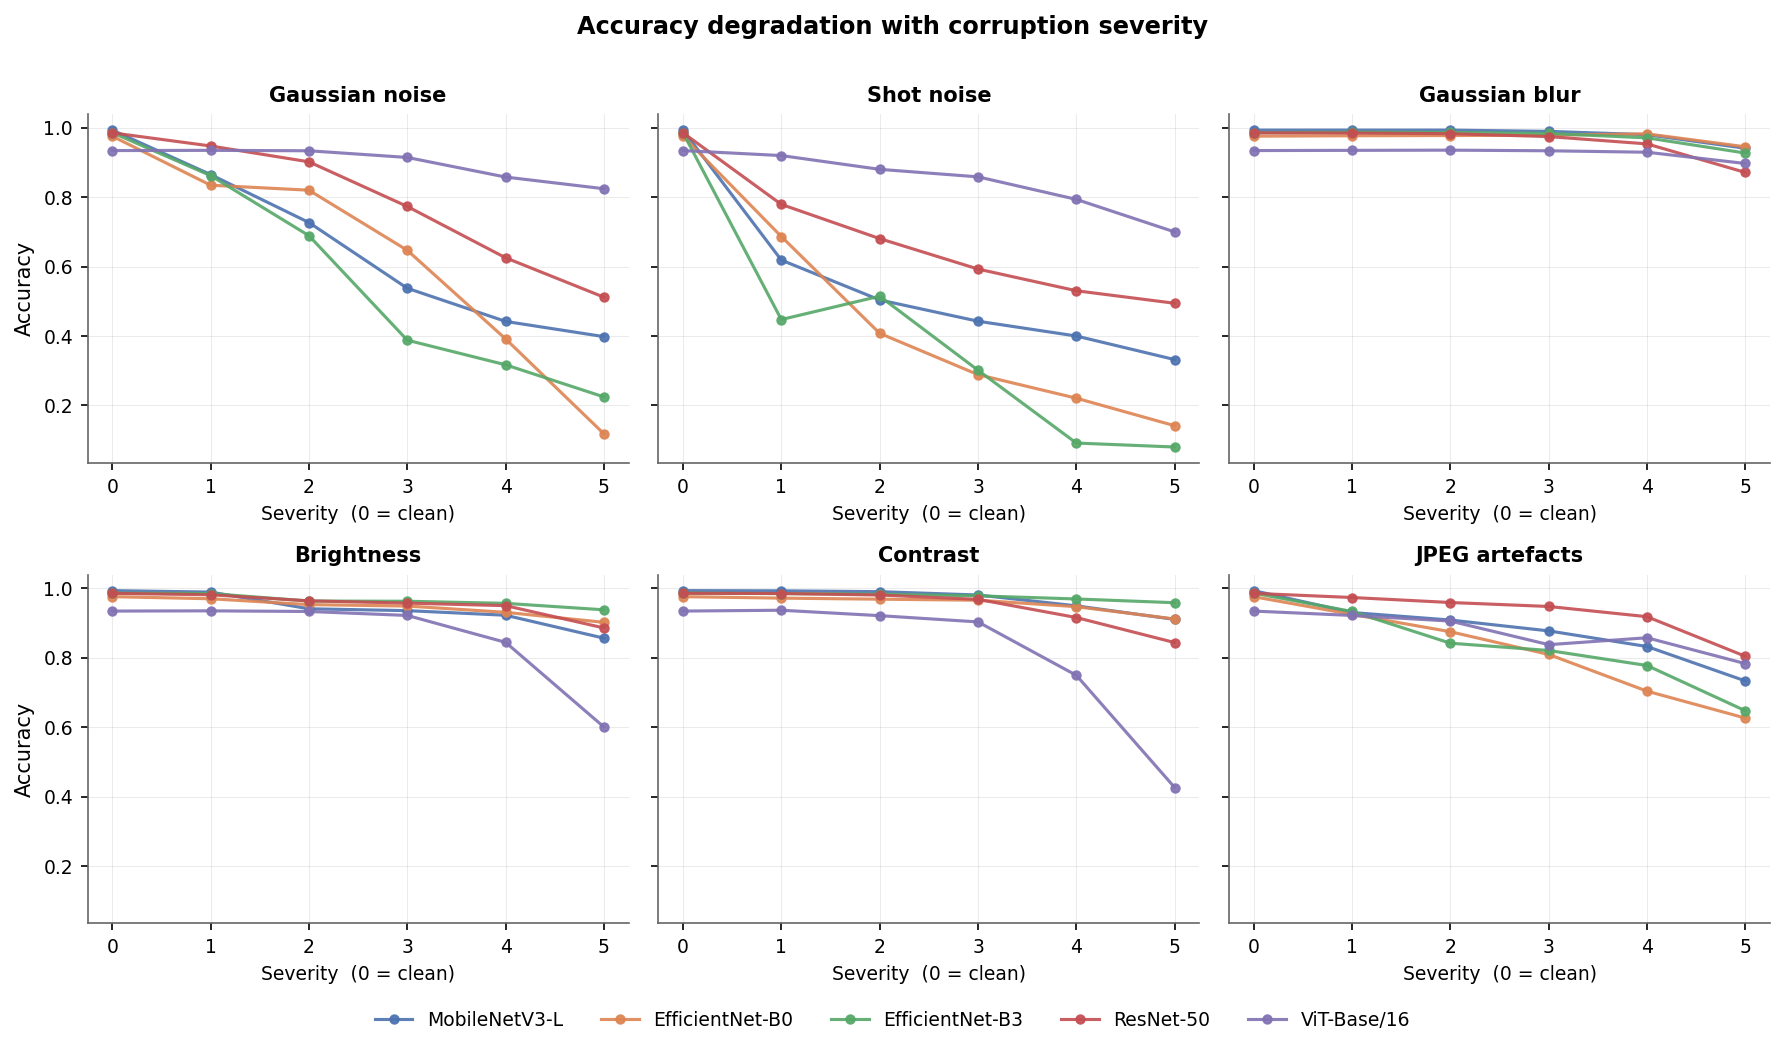

                 corrupted   clean  abs_drop_pp  rel_drop_pct
EfficientNet-B0     0.7606  0.9754      21.4815       22.0238
EfficientNet-B3     0.7488  0.9856      23.6817       24.0280
MobileNetV3-L       0.7968  0.9928      19.5996       19.7419
ResNet-50           0.8542  0.9850      13.0751       13.2744
ViT-Base/16         0.8571  0.9339       7.6817        8.2251


In [12]:
# ===== 4c. Robustness heatmap (Fig. 21) and degradation curves (Fig. 22) =====
mods=[m for m in PAL if m in set(rob.model)]

H=(rob[rob.corruption!='clean'].groupby(['corruption','model']).accuracy.mean()
     .unstack().reindex(index=CORRUPTIONS,columns=mods))
fig,ax=plt.subplots(figsize=(1.35*len(mods)+3.4,0.62*len(CORRUPTIONS)+2.8))
im=ax.imshow(H.values,cmap=light_cmap('YlGn',0,0.60),aspect='auto',
             vmin=max(0,np.floor(H.values.min()*20)/20),vmax=1.0)
ax.set_xticks(range(len(mods))); ax.set_xticklabels([NAT[m] for m in mods],
              rotation=25,ha='right',rotation_mode='anchor',fontsize=9)
ax.set_yticks(range(len(CORRUPTIONS)))
ax.set_yticklabels([PRETTY[c] for c in CORRUPTIONS],fontsize=9)
ax.set_xticks(np.arange(-.5,len(mods),1),minor=True)
ax.set_yticks(np.arange(-.5,len(CORRUPTIONS),1),minor=True)
ax.grid(which='minor',color='white',linewidth=1.6); ax.grid(which='major',visible=False)
ax.tick_params(which='minor',length=0)
for i in range(len(CORRUPTIONS)):
    for j in range(len(mods)):
        ax.text(j,i,f'{H.values[i,j]:.3f}',ha='center',va='center',fontsize=8.5,color='#111')
cb=fig.colorbar(im,ax=ax,fraction=.030,pad=.015)
cb.set_label(f'Accuracy, mean over severities {SEVERITIES[0]}-{SEVERITIES[-1]}',fontsize=9)
cb.outline.set_linewidth(.5)
ax.set_title('Accuracy under corruption on the common test set',pad=10)
plt.tight_layout(); save_fig(fig,'fig_robustness_heatmap',also_as='fig21'); plt.show()

n=len(CORRUPTIONS); ncol=3; nrow=int(np.ceil(n/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(4.0*ncol,3.3*nrow),squeeze=False,sharey=True)
for ax in axes.ravel(): ax.axis('off')
for k,cname in enumerate(CORRUPTIONS):
    ax=axes[k//ncol][k%ncol]; ax.axis('on')
    for m in mods:
        d=rob[(rob.model==m)&(rob.corruption==cname)].sort_values('severity')
        ax.plot([0]+d.severity.tolist(),[clean_acc[m]]+d.accuracy.tolist(),
                'o-',ms=4,lw=1.5,color=PAL_DK[m],alpha=.9,label=NAT[m])
    ax.set_title(PRETTY[cname],fontsize=10); ax.set_xticks([0]+SEVERITIES)
    ax.set_xlabel('Severity  (0 = clean)',fontsize=9)
    if k%ncol==0: ax.set_ylabel('Accuracy')
    ax.grid(alpha=.25)
h,l=axes[0][0].get_legend_handles_labels()
fig.legend(h,l,loc='lower center',ncol=len(mods),fontsize=9,bbox_to_anchor=(0.5,-0.04))
fig.suptitle('Accuracy degradation with corruption severity',fontsize=11.5,
             fontweight='bold',y=1.002)
plt.tight_layout(); save_fig(fig,'fig_robustness_degradation',also_as='fig22'); plt.show()

deg=(rob[rob.corruption!='clean'].groupby('model').accuracy.mean().to_frame('corrupted'))
deg['clean']=clean_acc
deg['abs_drop_pp']=(deg.clean-deg.corrupted)*100
deg['rel_drop_pct']=(1-deg.corrupted/deg.clean)*100
deg.index=[NAT[m] for m in deg.index]
deg.round(4).to_csv(OUT_DIR/'robustness_summary.csv')
print(deg.round(4).to_string())

## 5. Grad-CAM (Fig. 23)

Implemented with forward/backward hooks rather than an external package, so there is nothing
to install. One representative **correctly classified** image per class, from the reference CNN.

  saved fig_gradcam_per_class  (+ fig23)


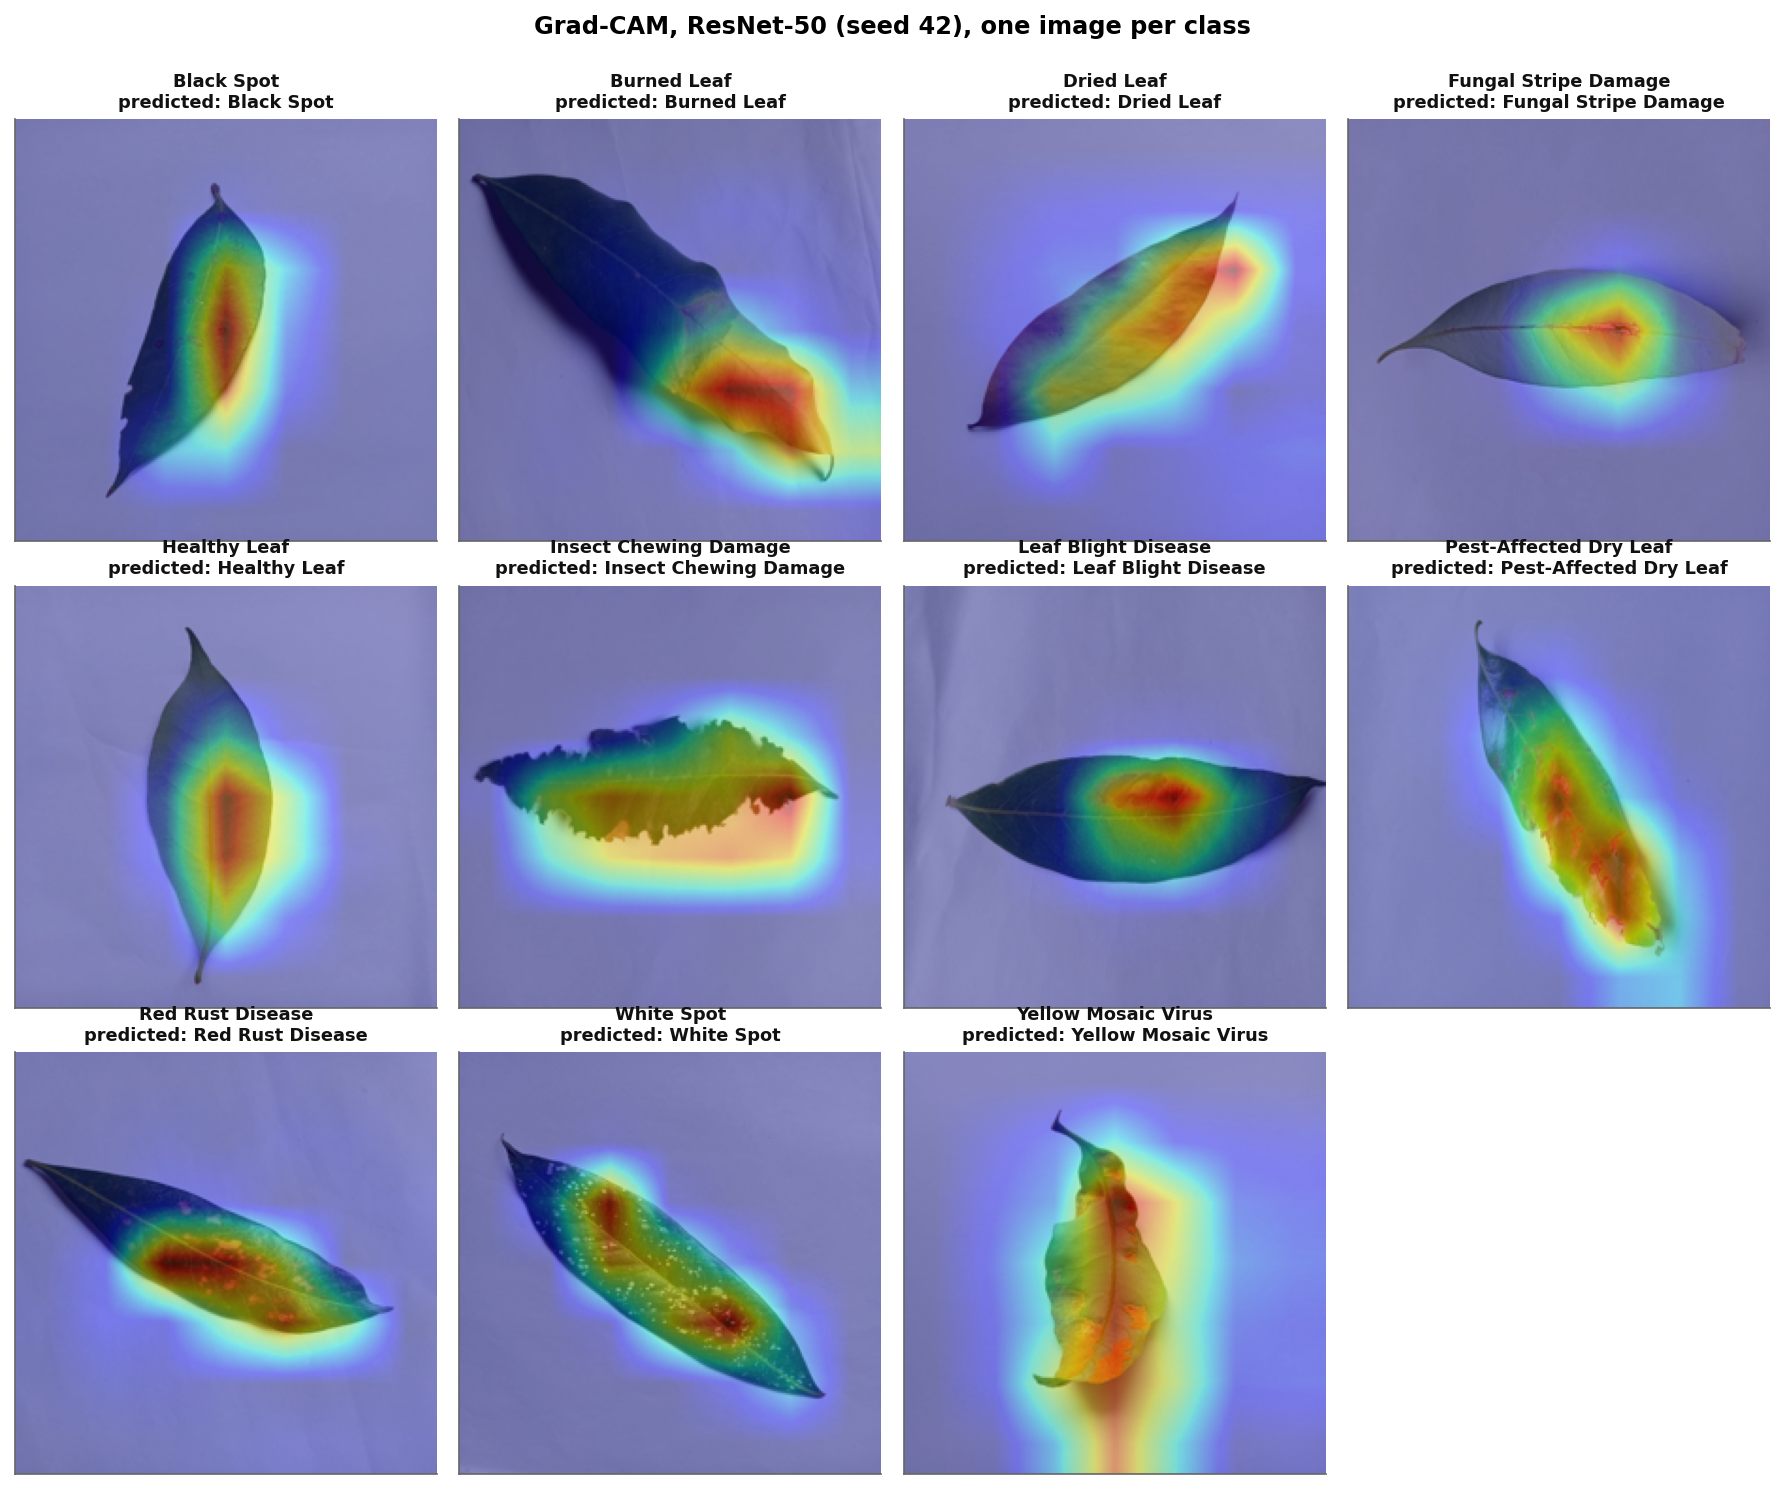

In [13]:
# ===== 5. Grad-CAM =====
GC_MODEL='ResNet50'
tag=f'{GC_MODEL}_seed{REF_SEED}'

def target_layer(name, model):
    if name=='ResNet50':         return model.layer4[-1]
    if name=='MobileNetV3Large': return model.features[-1]
    return model.blocks[-1]

if tag in CKPT:
    model,sz=build_backbone(GC_MODEL,NC)
    sd=torch.load(CKPT[tag],map_location='cpu')
    model.load_state_dict(sd['model'] if isinstance(sd,dict) and 'model' in sd else sd)
    model=model.to(DEVICE).eval()
    layer=target_layer(GC_MODEL,model)
    store={}
    layer.register_forward_hook(lambda m,i,o: store.__setitem__('a',o))
    layer.register_full_backward_hook(lambda m,gi,go: store.__setitem__('g',go[0]))

    ref=pred.get(tag)
    ok=(ref['y_pred']==ref['y_true']) if ref is not None else None
    picks=[]
    for ci,c in enumerate(CLASSES):
        sub=test[test.label==c]
        if ref is not None:
            good=set(ref['filename'][(ref['y_true']==ci)&ok])
            s2=sub[sub.filename.isin(good)]
            if len(s2): sub=s2
        if len(sub): picks.append(sub.iloc[0])
    tf=eval_transform(sz)

    ncol=4; nrow=int(np.ceil(len(picks)/ncol))
    fig,axes=plt.subplots(nrow,ncol,figsize=(3.0*ncol,3.3*nrow),squeeze=False)
    for ax in axes.ravel(): ax.axis('off')
    for k,r in enumerate(picks):
        img=Image.open(r.filepath).convert('RGB')
        x=tf(img).unsqueeze(0).to(DEVICE)
        model.zero_grad()
        out=model(x); cls=out.argmax(1)
        out[0,cls].backward()
        a,g=store['a'].detach(),store['g'].detach()
        w=g.mean(dim=(2,3),keepdim=True)
        cam=F.relu((w*a).sum(1,keepdim=True))
        cam=F.interpolate(cam,size=(sz,sz),mode='bilinear',align_corners=False)[0,0].cpu().numpy()
        cam=(cam-cam.min())/(cam.max()-cam.min()+1e-8)
        ax=axes[k//ncol][k%ncol]; ax.axis('on')
        ax.imshow(img.resize((sz,sz))); ax.imshow(cam,cmap='jet',alpha=0.42)
        pl=CLASSES[cls.item()]
        ax.set_title(f'{r.label}\npredicted: {pl}',fontsize=8.5,
                     color='#111' if pl==r.label else '#B22222')
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    fig.suptitle(f'Grad-CAM, {NAT[GC_MODEL]} (seed {REF_SEED}), one image per class',
                 fontsize=11.5,fontweight='bold',y=1.001)
    plt.tight_layout(); save_fig(fig,'fig_gradcam_per_class',also_as='fig23'); plt.show()
    del model; gc.collect()
    if DEVICE=='cuda': torch.cuda.empty_cache()
else:
    print(f'no checkpoint {tag} - Grad-CAM skipped')

In [14]:
# ===== 6. Wrap up =====
made=sorted(p.name for p in FIG.glob('*'))
print(f'{len(made)} files in {FIG}')
print('\nManuscript-numbered copies - drop these into bdlitchi_overleaf/figures/:')
for n in ['fig18','fig19','fig21','fig22','fig23','fig24','fig25']:
    f=FIG/f'{n}.pdf'
    print(f'  {n}.pdf  {"OK" if f.exists() else "MISSING"}')
print('\nCSVs:', sorted(p.name for p in OUT_DIR.glob('*.csv')))
print('''
All figures above use the NB03/NB04 checkpoints (trained on the specimen-disjoint
splits) and are scored on the common test set, so they are now consistent with
Figures 9-17 of the manuscript. Nothing here depends on the withdrawn
single-model ablation or the re-scored cross-validation.''')

30 files in /kaggle/working/revision_exploratory/figures

Manuscript-numbered copies - drop these into bdlitchi_overleaf/figures/:
  fig18.pdf  OK
  fig19.pdf  OK
  fig21.pdf  OK
  fig22.pdf  OK
  fig23.pdf  OK
  fig24.pdf  OK
  fig25.pdf  OK

CSVs: ['difficulty_by_class.csv', 'difficulty_per_image.csv', 'efficiency.csv', 'robustness.csv', 'robustness_summary.csv']

All figures above use the NB03/NB04 checkpoints (trained on the specimen-disjoint
splits) and are scored on the common test set, so they are now consistent with
Figures 9-17 of the manuscript. Nothing here depends on the withdrawn
single-model ablation or the re-scored cross-validation.
